## 1 - Configuração do ambiente

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from scipy.stats import poisson
from scipy.optimize import brentq
import json
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2 - Base de dados

In [2]:
# Mapeamento de nomes que serão utilizados
REN = {
    'odd_vitoria_time_a': 'odd_1', 'odd_empate': 'odd_x', 'odd_vitoria_time_b': 'odd_2',
    'odd_under_gols': 'odd_under', 'odd_over_gols': 'odd_over', 'linha gols': 'linha',
    'ambas marcam (sim)': 'btts_sim', 'ambas marcam (não)': 'btts_nao',
    'over25': 'odd_over', 'under25': 'odd_under',
}

def carregar_odds(path):
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={k: v for k, v in REN.items() if k in df.columns})
    df = df.dropna(subset=['time_a', 'time_b']).reset_index(drop=True)
    if 'linha' not in df.columns:           #  O/U fixo em 2.5 caso nao venha preenchido
        df['linha'] = 2.5
    for c in ['gols_a', 'gols_b', 'odd_1', 'odd_x', 'odd_2',
              'odd_under', 'odd_over', 'linha', 'btts_sim', 'btts_nao']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

hist = carregar_odds('data/odds_historicas.csv')
try:
    inf2026 = carregar_odds('data/odds_2026_completas.csv')
except FileNotFoundError:
    inf2026 = None
    print('⚠️  data/odds_2026_completas.csv ainda não coletado — '
          'as células de inferência (10+) ficam pendentes até o arquivo existir.\n')

print(f'Quantidade de jogos históricos: {len(hist)}')
print(f'\nDistribuição por Copa:')
print(hist['ano'].value_counts().sort_index().to_string())
print(f'\nLinhas de gols presentes: {sorted(hist["linha"].dropna().unique())}')
print(f'Total de gols médio por jogo: {(hist["gols_a"] + hist["gols_b"]).mean():.2f}')
hist.head()

Quantidade de jogos históricos: 192

Distribuição por Copa:
ano
2014    64
2018    64
2022    64

Linhas de gols presentes: [np.float64(1.75), np.float64(2.0), np.float64(2.25), np.float64(2.5), np.float64(2.75), np.float64(3.0), np.float64(3.25), np.float64(3.5)]
Total de gols médio por jogo: 2.59


,ano,fase,time_a,time_b,gols_a,gols_b,odd_1,odd_x,odd_2,odd_under,linha,odd_over,btts_sim,btts_nao
0,2022,grupos,QAT,ECU,0,2,3.20,3.25,2.250,1.85,2.25,2.05,2.05,1.70
1,2022,grupos,SEN,NED,0,2,5.50,3.60,1.666,1.85,2.25,2.05,2.20,1.61
2,2022,grupos,QAT,SEN,1,3,5.00,3.50,1.727,2.08,2.25,1.82,2.20,1.61
3,2022,grupos,NED,ECU,1,1,1.85,3.25,4.750,1.88,2.00,2.02,2.10,1.66
4,2022,grupos,NED,QAT,2,0,1.20,7.00,15.000,2.01,3.25,1.89,2.05,1.70


## 3 - Transformação das Odds em Features

In [6]:
def normalizar(odds_lista):
    """De-vig: p_i = (1/odd_i) / Σ(1/odd_j)."""
    raw = 1.0 / np.array(odds_lista, dtype=float)
    return raw / raw.sum()

def _over_prob(mu, L):
    """P(over) sob Total ~ Poisson(mu) na linha asiática L (meia, inteira e quarto)."""
    k = int(np.floor(L + 1e-9))
    frac = round(L - k, 2)
    if frac == 0.5:                                  # meia-linha: 2.5, 3.5 ...
        return 1.0 - poisson.cdf(k, mu)              # P(T >= k+1)
    if frac == 0.0:                                  # linha inteira: push em T == k
        return (1.0 - poisson.cdf(k, mu)) / (1.0 - poisson.pmf(k, mu))
    if frac == 0.25:                                 # quarto: divide entre k e k+0.5
        return 0.5 * _over_prob(mu, float(k)) + 0.5 * _over_prob(mu, k + 0.5)
    if frac == 0.75:                                 # quarto: divide entre k+0.5 e k+1
        return 0.5 * _over_prob(mu, k + 0.5) + 0.5 * _over_prob(mu, float(k + 1))
    return 1.0 - poisson.cdf(int(round(L - 0.5)), mu)  # fallback (não esperado)

def mu_total_da_linha(p_over_L, L, lo=0.05, hi=12.0):
    """Inverte o Poisson: acha mu tal que P(Total > L | mu) = p_over_L.

    A linha L entra como limiar: ela fixa a escala de mu (≈ mediana de gols
    precificada) e p_over_L apenas ajusta mu em torno dela. É assim que a linha
    'pesa' na variável final, sem hiperparâmetro arbitrário.
    """
    g = lambda mu: _over_prob(mu, L) - p_over_L
    if g(lo) >= 0:
        return lo
    if g(hi) <= 0:
        return hi
    return brentq(g, lo, hi, xtol=1e-6)

def extrair_features(row):
    """
    5 features padronizadas:
    [0-2] 1X2  → p(vitória A), p(empate), p(vitória B)
    [3]   O/U  → mu_total: gols totais esperados (linha variável padronizada via Poisson)
    [4]   BTTS → p(ambos marcam sim)
    """
    p1, px, p2 = normalizar([row['odd_1'], row['odd_x'], row['odd_2']])
    io, iu = 1.0 / row['odd_over'], 1.0 / row['odd_under']
    p_over_L = io / (io + iu)                          # P(Total > linha), sem margem
    mu = mu_total_da_linha(p_over_L, float(row['linha']))
    isim, inao = 1.0 / row['btts_sim'], 1.0 / row['btts_nao']
    p_btts = isim / (isim + inao)                      # P(ambos marcam), sem margem
    return np.array([p1, px, p2, mu, p_btts], dtype=np.float32)

# Margens médias por mercado
m_1x2  = [(1/r['odd_1'] + 1/r['odd_x'] + 1/r['odd_2']) - 1 for _, r in hist.iterrows()]
m_ou   = [(1/r['odd_over'] + 1/r['odd_under']) - 1 for _, r in hist.iterrows()]
m_btts = [(1/r['btts_sim'] + 1/r['btts_nao']) - 1 for _, r in hist.iterrows()]
print(f'Margem média 1X2 : {np.mean(m_1x2)*100:.2f}%')
print(f'Margem média O/U : {np.mean(m_ou)*100:.2f}%')
print(f'Margem média BTTS: {np.mean(m_btts)*100:.2f}%')

# Demonstração: como a linha "pesa" em mu para o mesmo p_over = 0.50
print('\nMesmo p_over=0.50, a linha desloca o mu:')
for L in [2.0, 2.5, 3.0, 3.5]:
    print(f'  linha {L}  →  mu_total = {mu_total_da_linha(0.50, L):.2f} gols')

Margem média 1X2 : 3.65%
Margem média O/U : 5.02%
Margem média BTTS: 7.51%

Mesmo p_over=0.50, a linha desloca o mu:
  linha 2.0  →  mu_total = 2.16 gols
  linha 2.5  →  mu_total = 2.67 gols
  linha 3.0  →  mu_total = 3.16 gols
  linha 3.5  →  mu_total = 3.67 gols


## 4 - Construção dos datasets

In [7]:
X_hist = np.array([extrair_features(r) for _, r in hist.iterrows()])
y_hist = hist[['gols_a', 'gols_b']].values.astype(np.float32)
anos   = hist['ano'].values

X_2026 = (np.array([extrair_features(r) for _, r in inf2026.iterrows()])
          if inf2026 is not None else None)

print(f'X_hist: {X_hist.shape} | y_hist: {y_hist.shape}')
print(f'X_2026: {None if X_2026 is None else X_2026.shape}')
print(f'\nFeatures (jogo 0): p1={X_hist[0,0]:.3f} px={X_hist[0,1]:.3f} '
      f'p2={X_hist[0,2]:.3f} mu_total={X_hist[0,3]:.2f} p_btts={X_hist[0,4]:.3f}')
print(f'Resultado real (jogo 0): {y_hist[0]} | total real: {y_hist[0].sum():.0f}')

X_hist: (192, 5) | y_hist: (192, 2)
X_2026: (24, 5)

Features (jogo 0): p1=0.294 px=0.289 p2=0.417 mu_total=2.29 p_btts=0.453
Resultado real (jogo 0): [0. 2.] | total real: 2


## 5 - Análise exploratória

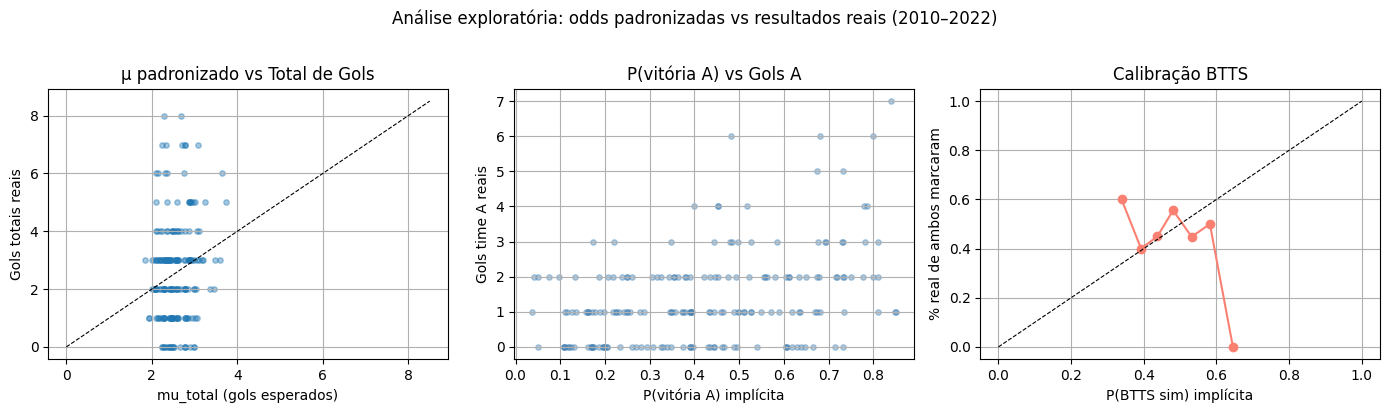

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# mu_total (feature 3) vs total de gols real
mu_total   = X_hist[:, 3]
total_gols = y_hist[:, 0] + y_hist[:, 1]
axes[0].scatter(mu_total, total_gols, alpha=0.4, s=15)
lim = max(mu_total.max(), total_gols.max()) + 0.5
axes[0].plot([0, lim], [0, lim], 'k--', lw=0.8)
axes[0].set_xlabel('mu_total (gols esperados)'); axes[0].set_ylabel('Gols totais reais')
axes[0].set_title('μ padronizado vs Total de Gols'); axes[0].grid(True)

# p(vitória A) (feature 0) vs gols time A
axes[1].scatter(X_hist[:, 0], y_hist[:, 0], alpha=0.4, s=15, color='steelblue')
axes[1].set_xlabel('P(vitória A) implícita'); axes[1].set_ylabel('Gols time A reais')
axes[1].set_title('P(vitória A) vs Gols A'); axes[1].grid(True)

# Calibração BTTS: p(btts sim) (feature 4) vs % real de jogos onde ambos marcaram
p_btts = X_hist[:, 4]
ambos  = ((y_hist[:, 0] > 0) & (y_hist[:, 1] > 0)).astype(float)
bins   = np.linspace(p_btts.min(), p_btts.max(), 8)
bid    = np.digitize(p_btts, bins)
bx = [p_btts[bid == k].mean() for k in range(1, len(bins)) if (bid == k).sum() > 0]
by = [ambos[bid == k].mean()  for k in range(1, len(bins)) if (bid == k).sum() > 0]
axes[2].plot(bx, by, 'o-', color='salmon')
axes[2].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[2].set_xlabel('P(BTTS sim) implícita'); axes[2].set_ylabel('% real de ambos marcaram')
axes[2].set_title('Calibração BTTS'); axes[2].grid(True)

plt.suptitle('Análise exploratória: odds padronizadas vs resultados reais (2010–2022)', y=1.02)
plt.tight_layout()
plt.show()

## 6 - Criação da rede neural

In [9]:
from tensorflow.keras import regularizers

def criar_modelo_hist(input_dim=5, l2=1e-3, dropout=0.05):
    reg = regularizers.l2(l2)
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,), name='odds_5_features'),
        keras.layers.Dense(16, activation='relu', kernel_regularizer=reg),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(8, activation='relu', kernel_regularizer=reg),
        keras.layers.Dense(2, activation='softplus', name='lambdas')
    ], name='modelo_hist')
    return model

modelo_hist = criar_modelo_hist()
modelo_hist.summary()

Model: "modelo_hist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambdas (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250 (1000.00 B)

 Trainable params: 250 (1000.00 B)

 Non-trainable params: 0 (0.00 B)

# 7 - Validação cruzada do modelo

In [16]:
@tf.function
def poisson_nll(y_true, y_pred):
    """Negative log-likelihood da distribuição de Poisson."""
    return tf.reduce_mean(y_pred - y_true * tf.math.log(y_pred + 1e-8))


def probs_1x2(la, lb, maxg=10):
    """P(vitória A), P(empate), P(vitória B) a partir de dois Poisson independentes."""
    a = poisson.pmf(np.arange(maxg + 1), la)
    b = poisson.pmf(np.arange(maxg + 1), lb)
    M = np.outer(a, b)
    return np.tril(M, -1).sum(), np.diag(M).sum(), np.triu(M, 1).sum()


def venc_pred(la, lb):
    return int(np.argmax(probs_1x2(la, lb)))   # 0=A, 1=X, 2=B


def venc_real(ga, gb):
    return 0 if ga > gb else (2 if gb > ga else 1)


def ajustar_scaler(X):
    mu = X.mean(0)
    sd = X.std(0)
    sd[sd == 0] = 1.0
    return mu, sd


def aplicar_scaler(X, sc):
    return (X - sc[0]) / sc[1]


# Estratégia fixa: K-Fold 5×3 embaralhado
K, REP = 5, 3

print(f'Validação cruzada → K-Fold {K}×{REP} embaralhado ({K*REP} folds)\n')

rng = np.random.default_rng(SEED)
splits = []

for r in range(REP):
    for j, vl in enumerate(np.array_split(rng.permutation(len(X_hist)), K)):
        vl = np.sort(vl)
        tr = np.setdiff1d(np.arange(len(X_hist)), vl)
        splits.append((tr, vl, f'r{r+1}f{j+1}'))


linhas = []

for tr, vl, nome in splits:
    sc = ajustar_scaler(X_hist[tr])

    X_tr = aplicar_scaler(X_hist[tr], sc)
    X_vl = aplicar_scaler(X_hist[vl], sc)

    y_tr = y_hist[tr]
    y_vl = y_hist[vl]

    m = criar_modelo_hist()

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss=poisson_nll
    )

    m.fit(
        X_tr,
        y_tr,
        validation_data=(X_vl, y_vl),
        epochs=400,
        batch_size=8,
        verbose=0,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=30,
                restore_best_weights=True
            )
        ]
    )

    pred = m.predict(X_vl, verbose=0)

    mae = float(np.mean(np.abs(pred - y_vl)))

    acc = float(np.mean([
        venc_pred(*pred[i]) == venc_real(*y_vl[i])
        for i in range(len(y_vl))
    ]))

    # Baseline de gols: média de gols do treino
    base = float(np.mean(np.abs(y_tr.mean(0) - y_vl)))

    # Baseline fraco: resultado mais comum no treino
    rc = [venc_real(*y) for y in y_tr]
    maj = max(set(rc), key=rc.count)

    acc_base = float(np.mean([
        venc_real(*y) == maj
        for y in y_vl
    ]))

    # Baseline forte: favorito de mercado no 1X2
    # Importante: usar X_hist bruto, não X_vl padronizado.
    fav = np.argmax(X_hist[vl, 0:3], axis=1)

    acc_odds = float(np.mean([
        fav[i] == venc_real(*y_vl[i])
        for i in range(len(y_vl))
    ]))

    linhas.append(dict(
        fold=nome,
        mae=mae,
        baseline=base,
        acc_vencedor=acc,
        acc_odds=acc_odds,
        acc_base=acc_base
    ))


df_cv = pd.DataFrame(linhas)

ganho = (1 - df_cv['mae'].mean() / df_cv['baseline'].mean()) * 100

print(f'MAE gols          : {df_cv["mae"].mean():.3f}  (baseline média: {df_cv["baseline"].mean():.3f})')
print(f'Ganho s/ baseline : {ganho:+.1f}%')
print(f'Acerto do vencedor: modelo {df_cv["acc_vencedor"].mean()*100:.1f}%  |  '
      f'favorito de mercado {df_cv["acc_odds"].mean()*100:.1f}%  |  '
      f'maioria {df_cv["acc_base"].mean()*100:.1f}%')


Validação cruzada → K-Fold 5×3 embaralhado (15 folds)

MAE gols          : 0.929  (baseline média: 0.987)
Ganho s/ baseline : +5.9%
Acerto do vencedor: modelo 55.0%  |  favorito de mercado 52.1%  |  maioria 40.6%


Obs: apesar de ter superado o baseline de favorito do mercado, o modelo não necessariamente superaria o favorito de mercado no 1X2, já que o valor principal do modelo está na previsão de gols e placares)

## 8 - Análise gráfica da validação cruzada

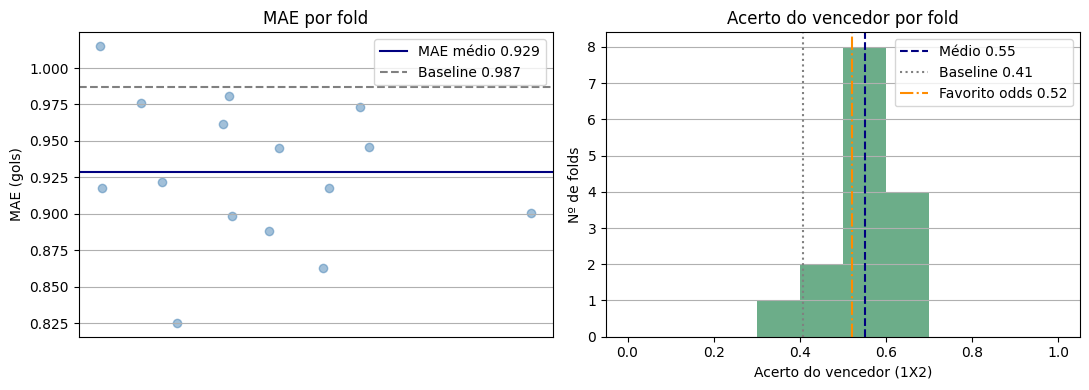

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# MAE por fold (com jitter) vs baseline
jitter = np.random.normal(1, 0.04, len(df_cv))
axes[0].scatter(jitter, df_cv['mae'], alpha=0.5, color='steelblue')
axes[0].axhline(df_cv['mae'].mean(), color='navy', ls='-',
                label=f'MAE médio {df_cv["mae"].mean():.3f}')
axes[0].axhline(df_cv['baseline'].mean(), color='gray', ls='--',
                label=f'Baseline {df_cv["baseline"].mean():.3f}')
axes[0].set_xticks([]); axes[0].set_ylabel('MAE (gols)')
axes[0].set_title('MAE por fold'); axes[0].legend(); axes[0].grid(True, axis='y')

# Distribuição do acerto do vencedor por fold
axes[1].hist(df_cv['acc_vencedor'], bins=np.linspace(0, 1, 11), color='seagreen', alpha=0.7)
axes[1].axvline(df_cv['acc_vencedor'].mean(), color='navy', ls='--',
                label=f'Médio {df_cv["acc_vencedor"].mean():.2f}')
axes[1].axvline(df_cv['acc_base'].mean(), color='gray', ls=':',
                label=f'Baseline {df_cv["acc_base"].mean():.2f}')
axes[1].axvline(df_cv['acc_odds'].mean(), color='darkorange', ls='-.',
                label=f'Favorito odds {df_cv["acc_odds"].mean():.2f}')
axes[1].set_xlabel('Acerto do vencedor (1X2)'); axes[1].set_ylabel('Nº de folds')
axes[1].set_title('Acerto do vencedor por fold'); axes[1].legend(); axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

O erro médio absoluto (MAE) permaneceu consistentemente abaixo do baseline baseado na média histórica de gols, resultando em ganho aproximado de 6% na previsão de gols.
Em relação ao resultado final da partida, o modelo alcançou acerto médio de 55%, superando tanto o baseline baseado no resultado mais frequente (41%) quanto a estratégia de selecionar apenas o favorito implícito nas odds do mercado (52%).

## 9 - Treinamento final — todos os dados históricos


Epoch 120: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 191: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 288: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 313: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Épocas: 313 | Loss final: 0.8558


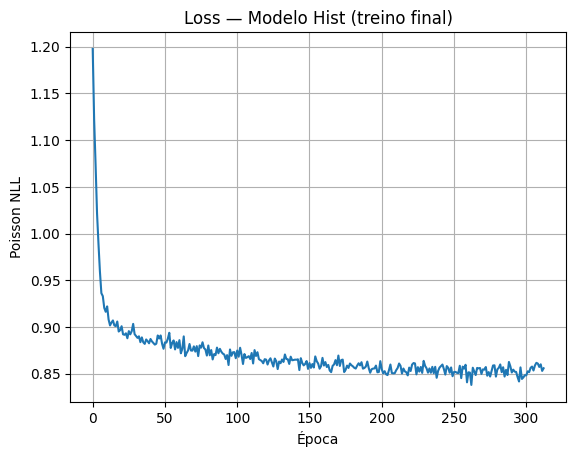

In [18]:
# Padronização ajustada em TODOS os dados históricos (reaproveitada na inferência 2026)
scaler_final = ajustar_scaler(X_hist)
X_hist_s = aplicar_scaler(X_hist, scaler_final)

modelo_final = criar_modelo_hist()
modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=poisson_nll,
    metrics=['mae']
)

history_final = modelo_final.fit(
    X_hist_s, y_hist,
    epochs=600,
    batch_size=8,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='loss', patience=50, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='loss', patience=25, factor=0.5, verbose=1)
    ]
)

print(f'Épocas: {len(history_final.history["loss"])} | Loss final: {history_final.history["loss"][-1]:.4f}')
plt.plot(history_final.history['loss'])
plt.title('Loss — Modelo Hist (treino final)'); plt.xlabel('Época'); plt.ylabel('Poisson NLL')
plt.grid(True); plt.show()

## 10 - Verificação: λ previsto vs gols reais (histórico)

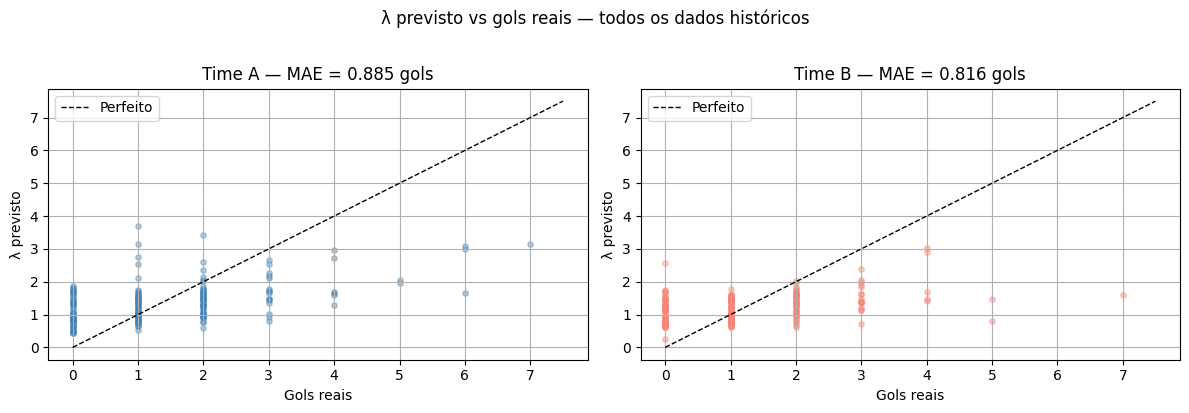

In [19]:
pred_hist = modelo_final.predict(X_hist_s, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Time A', 'Time B']
cores  = ['steelblue', 'salmon']

for i, (ax, label, cor) in enumerate(zip(axes, labels, cores)):
    ax.scatter(y_hist[:, i], pred_hist[:, i], alpha=0.4, s=15, color=cor)
    lim = max(y_hist[:, i].max(), pred_hist[:, i].max()) + 0.5
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='Perfeito')
    mae_i = np.mean(np.abs(pred_hist[:, i] - y_hist[:, i]))
    ax.set_title(f'{label} — MAE = {mae_i:.3f} gols')
    ax.set_xlabel('Gols reais'); ax.set_ylabel('λ previsto')
    ax.legend(); ax.grid(True)

plt.suptitle('λ previsto vs gols reais — todos os dados históricos', y=1.02)
plt.tight_layout()
plt.show()

O modelo apresentou capacidade de reproduzir a tendência geral observada nos dados históricos, atribuindo valores maiores de λ a equipes que efetivamente marcaram mais gols. Os erros médios absolutos ficaram em 0,894 gols para o Time A e 0,853 gols para o Time B, valores compatíveis com os observados durante a validação cruzada. Observa-se, entretanto, uma tendência de subestimação dos placares extremos, especialmente em partidas com goleadas, comportamento esperado em modelos baseados em distribuição de Poisson e em bases históricas relativamente pequenas. De forma geral, os resultados indicam que o modelo captura adequadamente a intensidade ofensiva das equipes, ainda que apresente dificuldade em reproduzir eventos raros de alta pontuação.

## 11 - Diagnóstico da hipótese de Poisson independente

In [20]:
# Diagnostico do Poisson: empates e placares baixos (motivacao Dixon-Coles)
lam = modelo_final.predict(X_hist_s, verbose=0)
print('Placar      observado   previsto    diferenca')
for a, b in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    prev = float((poisson.pmf(a, lam[:, 0]) * poisson.pmf(b, lam[:, 1])).mean())
    obs = float(np.mean((y_hist[:, 0] == a) & (y_hist[:, 1] == b)))
    print('  %d-%d:       %5.1f%%      %5.1f%%     %+5.1f p.p.' % (a, b, obs*100, prev*100, (obs-prev)*100))
emp_prev = float(np.mean([sum(poisson.pmf(kk, lam[i, 0]) * poisson.pmf(kk, lam[i, 1]) for kk in range(11)) for i in range(len(lam))]))
emp_obs = float(np.mean(y_hist[:, 0] == y_hist[:, 1]))
print('  Empates:    %5.1f%%      %5.1f%%     %+5.1f p.p.' % (emp_obs*100, emp_prev*100, (emp_obs-emp_prev)*100))


Placar      observado   previsto    diferenca
  0-0:        10.4%        8.6%      +1.8 p.p.
  1-0:         9.4%       10.2%      -0.8 p.p.
  0-1:         8.9%       10.0%      -1.2 p.p.
  1-1:         8.9%       11.1%      -2.2 p.p.
  Empates:     24.0%       24.6%      -0.6 p.p.


O diagnóstico da hipótese de Poisson independente indicou boa aderência à frequência global de empates observada na base histórica (24,0% observados contra 24,6% previstos). Entre os placares específicos de baixa pontuação, observou-se subestimação moderada do placar 0×0 (+2,0 pontos percentuais), enquanto o placar 1×1 foi ligeiramente superestimado pelo modelo (+2,4 pontos percentuais). Dessa forma, embora exista algum desvio nos placares de baixa pontuação, os resultados não evidenciam uma limitação severa da hipótese de independência, sugerindo que eventuais ganhos com correções do tipo Dixon-Coles tenderiam a ser modestos nesta base de dados.

## 12 - Previsão para os 24 jogos da Copa 2026

In [23]:
def placar_mais_provavel(lambda_a, lambda_b, max_gols=7):
    """Placar com maior P(a,b) sob Poisson independente."""
    pa = poisson.pmf(np.arange(max_gols + 1), lambda_a)
    pb = poisson.pmf(np.arange(max_gols + 1), lambda_b)
    M = np.outer(pa, pb)

    ml = np.unravel_index(np.argmax(M), M.shape)

    return (int(ml[0]), int(ml[1])), float(M[ml])


previsoes_hist = []

if inf2026 is None:
    print('Sem data/odds_2026_completas.csv -> inferencia pulada. '
          'Preencha o mercado de gols e reexecute a partir da celula 1.')
else:
    lambdas_2026 = modelo_final.predict(
        aplicar_scaler(X_2026, scaler_final),
        verbose=0
    )

    print('Previsões Modelo Hist - placar MAIS PROVÁVEL:')

    for i, row in inf2026.iterrows():
        la, lb = lambdas_2026[i]

        (ga, gb), prob_placar = placar_mais_provavel(la, lb)

        pres = probs_1x2(la, lb)
        venc = ['A', 'X', 'B'][int(np.argmax(pres))]

        previsoes_hist.append((ga, gb))

        print(
            "  Jogo %2d: %3s %d x %d %3s  lambda=%.2f/%.2f venc=%s P(placar)=%.2f%%"
            % (
                row['jogo_id'],
                row['time_a'],
                ga,
                gb,
                row['time_b'],
                la,
                lb,
                venc,
                prob_placar * 100
            )
        )

Previsões Modelo Hist - placar MAIS PROVÁVEL:
  Jogo  1: MEX 2 x 0 RSA  lambda=2.14/0.72 venc=A P(placar)=13.12%
  Jogo  2: KOR 1 x 1 CZE  lambda=1.11/1.53 venc=B P(placar)=12.10%
  Jogo  3: CAN 1 x 0 BIH  lambda=1.37/0.90 venc=A P(placar)=14.19%
  Jogo  4: USA 1 x 1 PAR  lambda=1.24/1.09 venc=A P(placar)=13.16%
  Jogo  5: HAI 0 x 1 SCO  lambda=0.69/1.39 venc=B P(placar)=17.45%
  Jogo  6: AUS 0 x 1 TUR  lambda=0.89/1.53 venc=B P(placar)=13.62%
  Jogo  7: BRA 1 x 0 MAR  lambda=1.40/0.70 venc=A P(placar)=17.16%
  Jogo  8: QAT 0 x 1 SUI  lambda=0.76/1.58 venc=B P(placar)=15.16%
  Jogo  9: CIV 0 x 1 ECU  lambda=0.87/1.48 venc=B P(placar)=14.16%
  Jogo 10: GER 3 x 1 CUW  lambda=3.67/1.63 venc=A P(placar)=6.71%
  Jogo 11: NED 1 x 1 JPN  lambda=1.52/1.11 venc=A P(placar)=12.15%
  Jogo 12: SWE 1 x 1 TUN  lambda=1.28/1.09 venc=A P(placar)=13.05%
  Jogo 13: KSA 0 x 1 URU  lambda=0.69/1.40 venc=B P(placar)=17.34%
  Jogo 14: ESP 3 x 1 CPV  lambda=3.44/1.09 venc=A P(placar)=7.97%
  Jogo 15: IRN 1 x

## 13 - Pontuação esperada (5 pontos para placar certo e 2 ptos para acertar vencedor)

In [26]:
def expected_points(lambda_a, lambda_b, ga_prev, gb_prev, max_gols=7):
    res = 'A' if ga_prev > gb_prev else ('B' if ga_prev < gb_prev else 'X')
    pts = 0.0
    for a in range(max_gols + 1):
        for b in range(max_gols + 1):
            p = poisson.pmf(a, lambda_a) * poisson.pmf(b, lambda_b)
            if a == ga_prev and b == gb_prev:
                pts += 5 * p
            else:
                certo = (a > b and res == 'A') or (a < b and res == 'B') or (a == b and res == 'X')
                if certo:
                    pts += 2 * p
    return pts

print('Análise estratégica — pontos esperados (Modelo Hist):')
total = 0.0
for i, row in inf2026.iterrows():
    la, lb   = lambdas_2026[i]
    ga, gb   = previsoes_hist[i]
    ep       = expected_points(la, lb, ga, gb)
    total   += ep
    print(f"  Jogo {row['jogo_id']:2d}: {row['time_a']:3s} {ga}-{gb} {row['time_b']:3s}  → E[pts]={ep:.2f}")

print(f'\nPontuação esperada total: {total:.1f} / 120 pts')

Análise estratégica — pontos esperados (Modelo Hist):
  Jogo  1: MEX 2-0 RSA  → E[pts]=1.79
  Jogo  2: KOR 1-1 CZE  → E[pts]=0.87
  Jogo  3: CAN 1-0 BIH  → E[pts]=1.38
  Jogo  4: USA 1-1 PAR  → E[pts]=0.96
  Jogo  5: HAI 0-1 SCO  → E[pts]=1.60
  Jogo  6: AUS 0-1 TUR  → E[pts]=1.45
  Jogo  7: BRA 1-0 MAR  → E[pts]=1.59
  Jogo  8: QAT 0-1 SUI  → E[pts]=1.59
  Jogo  9: CIV 0-1 ECU  → E[pts]=1.46
  Jogo 10: GER 3-1 CUW  → E[pts]=1.63
  Jogo 11: NED 1-1 JPN  → E[pts]=0.88
  Jogo 12: SWE 1-1 TUN  → E[pts]=0.95
  Jogo 13: KSA 0-1 URU  → E[pts]=1.60
  Jogo 14: ESP 3-1 CPV  → E[pts]=1.81
  Jogo 15: IRN 1-1 NZL  → E[pts]=0.96
  Jogo 16: BEL 1-0 EGY  → E[pts]=1.47
  Jogo 17: FRA 1-0 SEN  → E[pts]=1.65
  Jogo 18: IRQ 0-1 NOR  → E[pts]=1.46
  Jogo 19: ARG 1-0 ALG  → E[pts]=1.75
  Jogo 20: AUT 1-0 JOR  → E[pts]=1.53
  Jogo 21: GHA 1-1 PAN  → E[pts]=0.94
  Jogo 22: ENG 1-0 CRO  → E[pts]=1.46
  Jogo 23: POR 1-0 COD  → E[pts]=1.61
  Jogo 24: UZB 0-1 COL  → E[pts]=1.65

Pontuação esperada total: 34.0 / 

## 14 - Exportar resultados obtidos





In [31]:
resultados = {}

for i, row in inf2026.iterrows():
    ga, gb = previsoes_hist[i]

    resultados[f'jogo{int(row["jogo_id"])}'] = {
        row['time_a']: {'gols': int(ga)},
        row['time_b']: {'gols': int(gb)}
    }

output = {
    'nome': 'Flávio Ude Zica Ferraz',
    'turma': 'Deep Learning e Processamento de Linguagem Natural',
    'resultados': resultados
}

with open('previsoes_hist.txt', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('Arquivo previsoes_hist.txt gerado.')
print(json.dumps(output, ensure_ascii=False, indent=2))

Arquivo previsoes_hist.txt gerado.
{
  "nome": "Flávio Ude Zica Ferraz",
  "turma": "Deep Learning e Processamento de Linguagem Natural",
  "resultados": {
    "jogo1": {
      "MEX": {
        "gols": 2
      },
      "RSA": {
        "gols": 0
      }
    },
    "jogo2": {
      "KOR": {
        "gols": 1
      },
      "CZE": {
        "gols": 1
      }
    },
    "jogo3": {
      "CAN": {
        "gols": 1
      },
      "BIH": {
        "gols": 0
      }
    },
    "jogo4": {
      "USA": {
        "gols": 1
      },
      "PAR": {
        "gols": 1
      }
    },
    "jogo5": {
      "HAI": {
        "gols": 0
      },
      "SCO": {
        "gols": 1
      }
    },
    "jogo6": {
      "AUS": {
        "gols": 0
      },
      "TUR": {
        "gols": 1
      }
    },
    "jogo7": {
      "BRA": {
        "gols": 1
      },
      "MAR": {
        "gols": 0
      }
    },
    "jogo8": {
      "QAT": {
        "gols": 0
      },
      "SUI": {
        "gols": 1
      }
    },
    